# Option Pricing Comparison with Tenokonda Sobol' Sequence

In this notebook we repeat the deterministic Sobol' comparison for a **discretely monitored geometric Asian call**.

## Pricing a geometric Asian option with Monte Carlo and quasi-Monte Carlo

Under the risk-neutral Black--Scholes model,
$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t^{\mathbb{Q}},
\qquad S_0 > 0,
$$
with monitoring dates
$$
0 < t_1 < t_2 < \cdots < t_d = T,
\qquad t_i = iT/d.
$$

The discrete geometric average is
$$
G_d = \left(\prod_{i=1}^{d} S_{t_i}\right)^{1/d},
$$
and the time-zero value of a call with strike $K$ is
$$
A_0(d) = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[(G_d-K)^+\right].
$$

Using the standard chronological time-stepping scheme,
$$
S_{t_i} = S_0 \exp\!\left(\left(r-\tfrac12\sigma^2\right)t_i + \sigma\sqrt{T/d}\sum_{j=1}^{i} Z_j\right),
\qquad Z_j \sim N(0,1).
$$
From this one obtains
$$
\log G_d \sim N(m_d, v_d),
$$
with
$$
m_d = \log S_0 + \left(r-\tfrac12\sigma^2\right)T\frac{d+1}{2d},
\qquad
v_d = \sigma^2 T\frac{(d+1)(2d+1)}{6d^2}.
$$
Hence the benchmark price is available in closed form:
$$
A_0(d)=e^{-rT}\left(e^{m_d+\tfrac12 v_d}N\!\left(\frac{m_d-\log K+v_d}{\sqrt{v_d}}\right)-K N\!\left(\frac{m_d-\log K}{\sqrt{v_d}}\right)\right).
$$

In [1]:
from pricing_helper import *
from plotting_helper import plot_with_error_panel
from tklds.interface.generators import get_sequence_enum

In [2]:
num_paths = 2**12
spot = 100.0
strike = 100.0
rate = 0.05
volatility = 0.2
expiry = 0.5
cp = 1

tk_dimension_grid_a = np.arange(2, 50001)
jk_dimension_grid_b = np.arange(2, 21021)

sequence_enum = get_sequence_enum()

tk_sequence = sequence_enum.TKRG_A_AP5
jk_sequence = sequence_enum.NEW_JOE_KUO

tk_normals = sobol_normal_matrix(
    num_paths=num_paths,
    num_dimensions=int(tk_dimension_grid_a.max()),
    sequence=tk_sequence,
)
jk_normals = sobol_normal_matrix(
    num_paths=num_paths,
    num_dimensions=int(jk_dimension_grid_b.max()),
    sequence=jk_sequence,
)

In [3]:
asian_reference_price, tk_prices, jk_prices = run_sobol_geometric_asian_price_comparison(
    spot=spot,
    strike=strike,
    rate=rate,
    volatility=volatility,
    expiry=expiry,
    z_a=tk_normals,
    z_b=jk_normals,
    dimension_grid_a=tk_dimension_grid_a,
    dimension_grid_b=jk_dimension_grid_b,
    cp=cp,
)

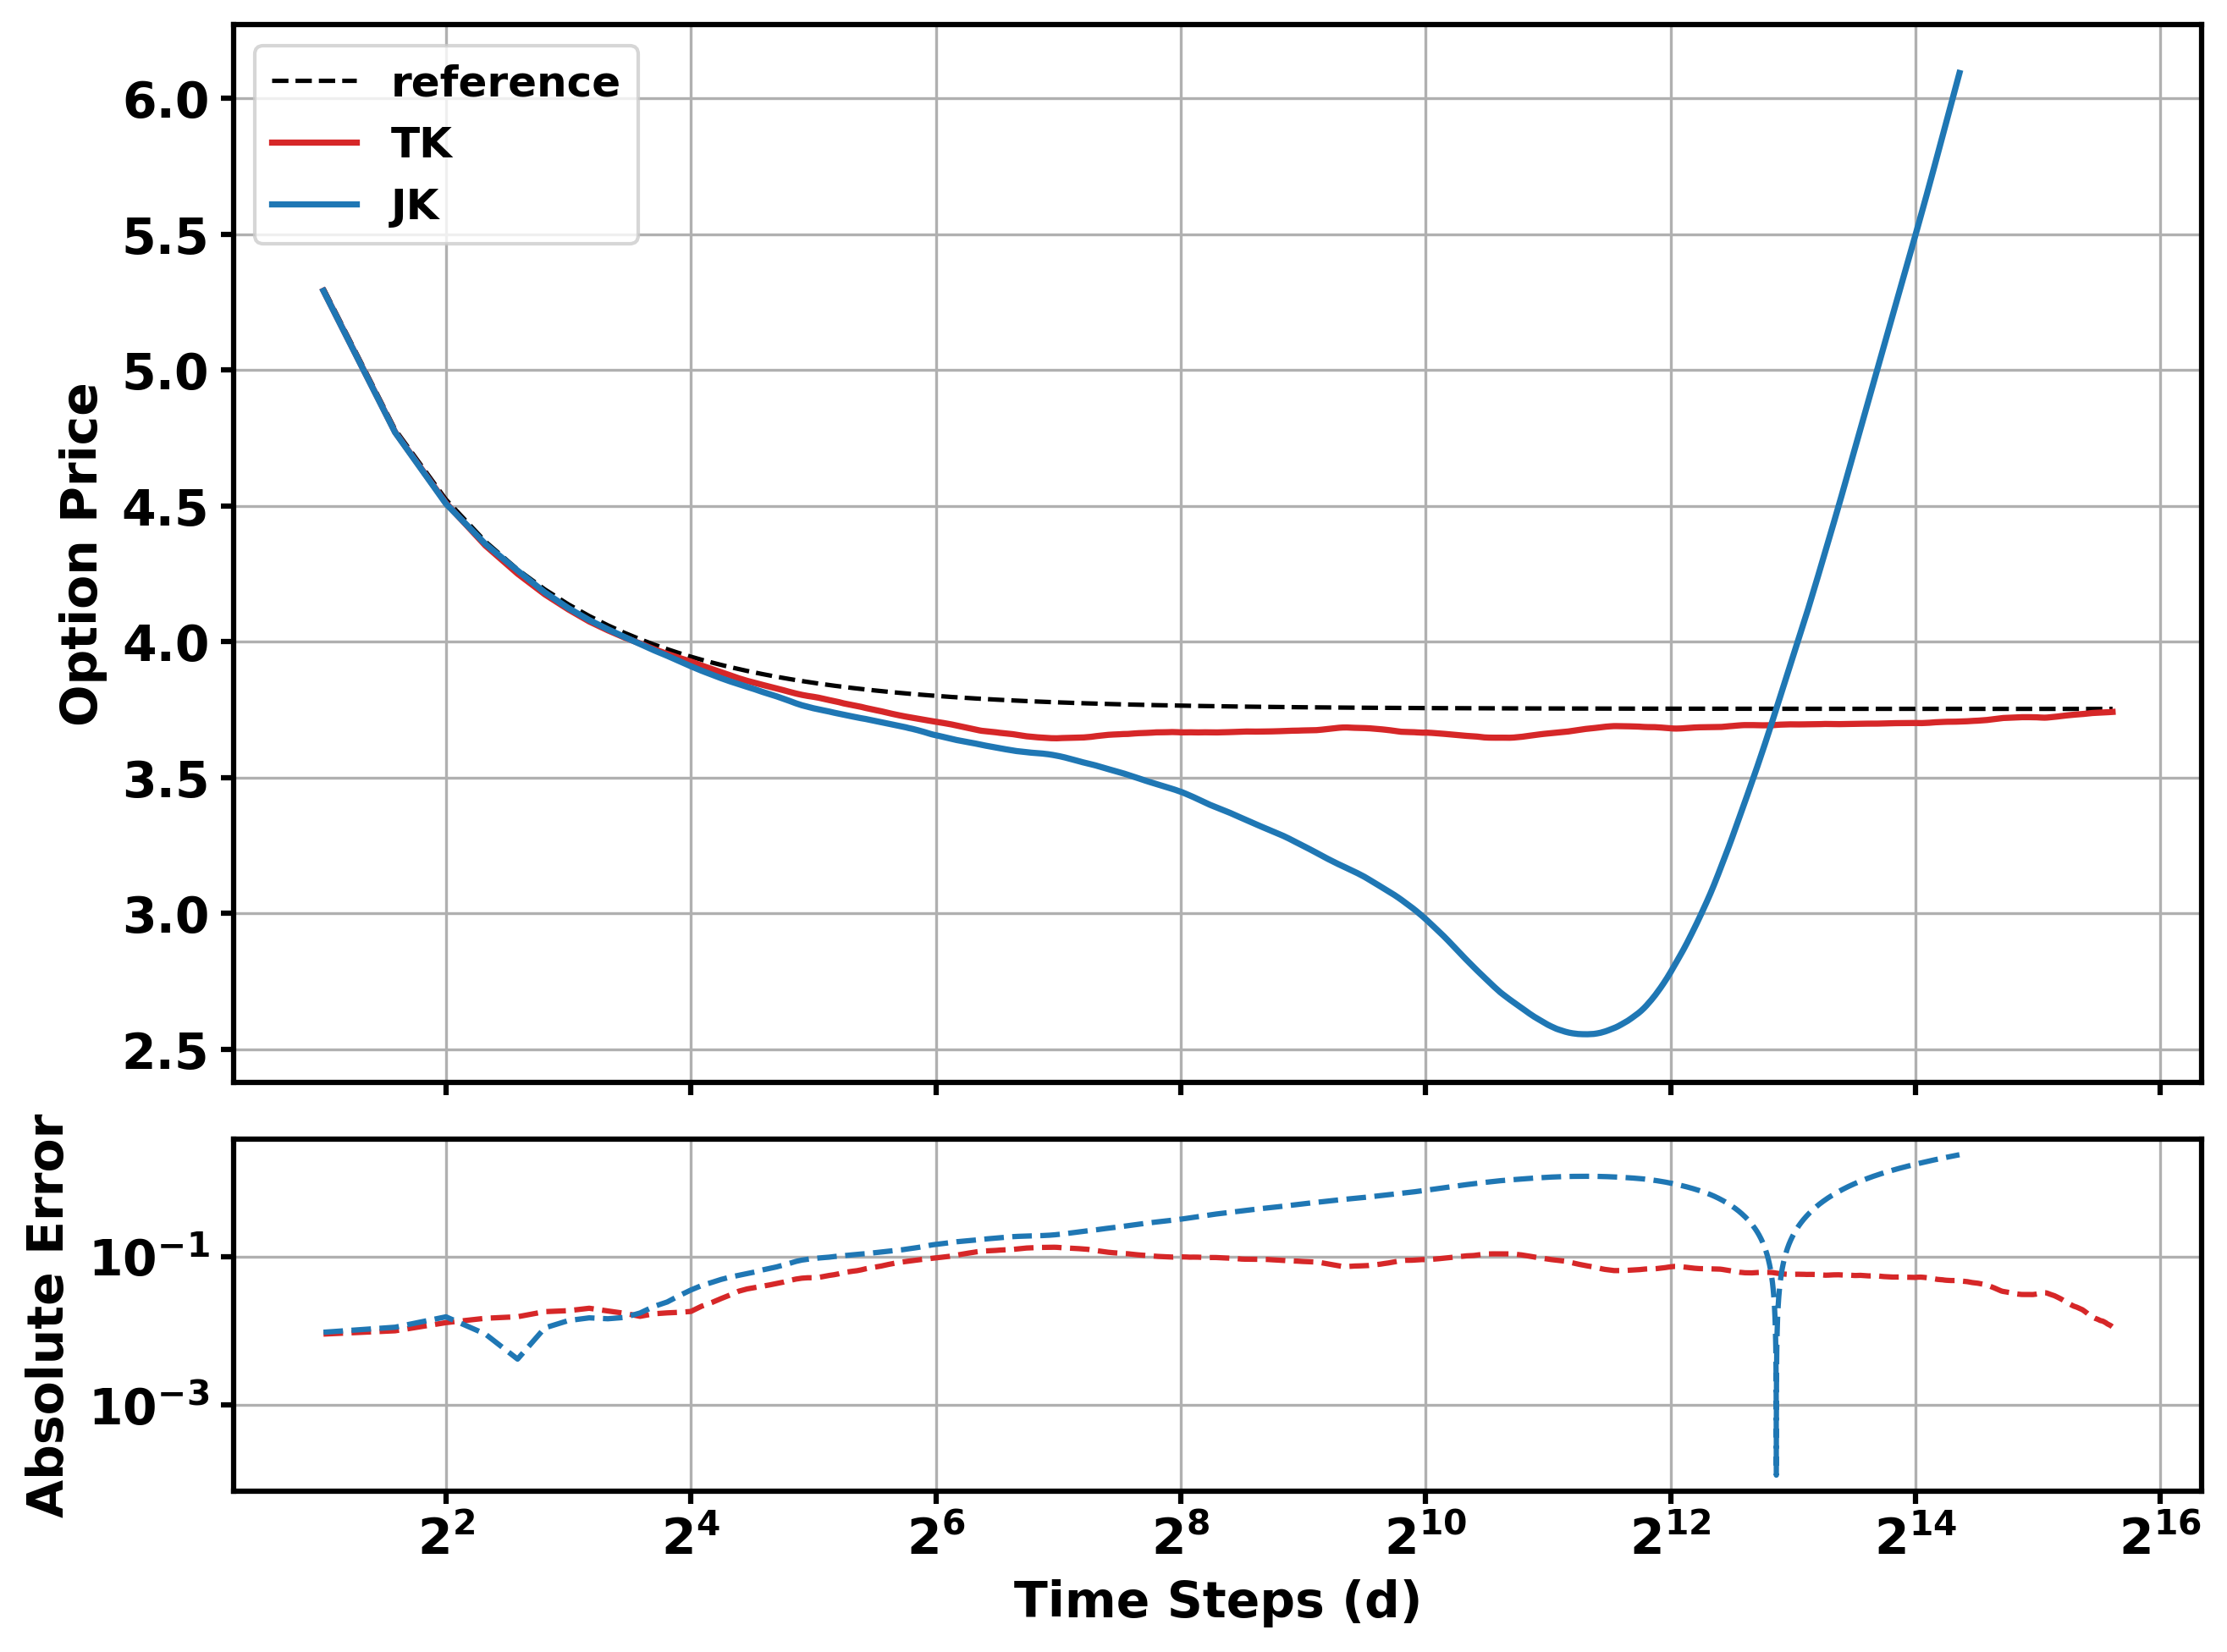

(<Figure size 3000x2250 with 2 Axes>,
 (<Axes: ylabel='Option Price'>,
  <Axes: xlabel='Time Steps (d)', ylabel='Absolute Error'>))

In [4]:
plot_with_error_panel(
    x_data=[tk_dimension_grid_a, jk_dimension_grid_b],
    y_data=[tk_prices, jk_prices],
    y_axis_label_top='Option Price',
    y_axis_label_bottom='Absolute Error',
    x_axis_label='Time Steps (d)',
    y_data_label=['TK', 'JK'],
    y_data_colors=['tab:red', 'tab:blue'],
    reference_x_data=tk_dimension_grid_a,
    reference_y_data=asian_reference_price,
)